Omega_r=
418.8790204786391
Omega_A=
1361.356816555577
Delta_r=
5026.548245743669
Delta_A=
53092.9158456675
V=
5014.91271739704
t_g=
1.0182337649086282


d:\ScienceAPPs\Anaconda\envs\Quantum_tools_in_python\Lib\site-packages\qutip\solver\options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


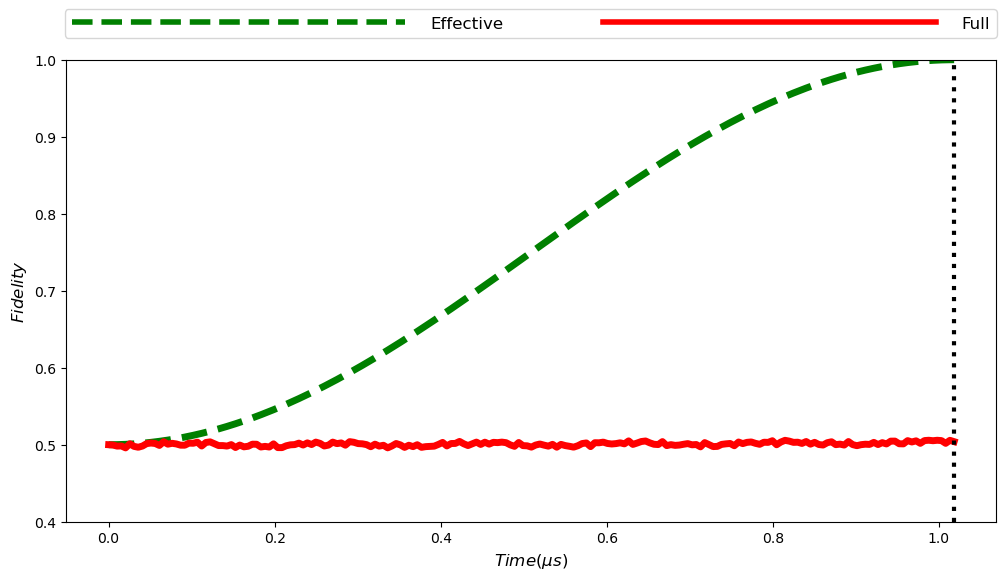

Omega_r=
418.8790204786391
Delta_r=
5026.548245743669
V=
5014.91271739704
t_g=
1.0182337649086282


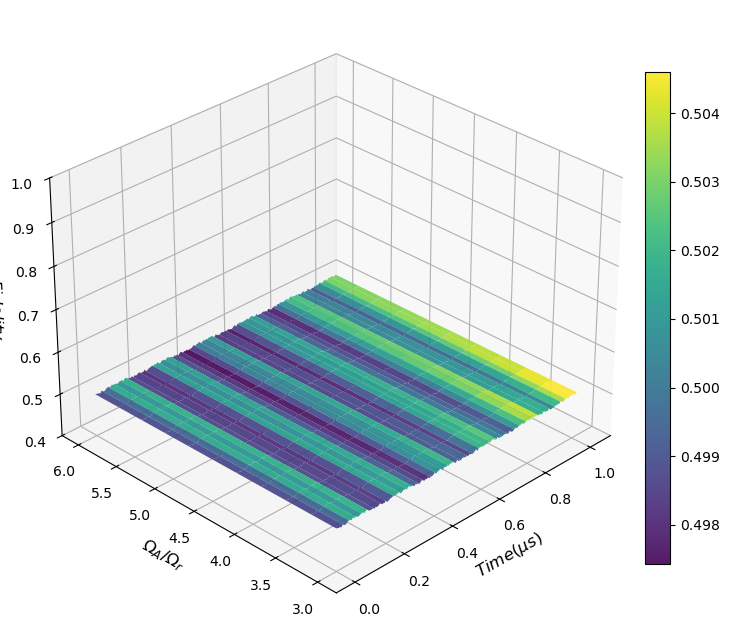

In [1]:
from qutip import * 
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import re
#  # 读取 Mathematica 导出的 H_full 矩阵
# H_V = np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\HV.dat", dtype=complex)              ##  H_V相互作用矩阵，只有主对角线元素
# H_r0_plus = np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Hr0.dat", dtype=complex)       ##  H_full中只留与 r 有关项的上三角”元矩阵“(矩阵元均为1，起到占位的作用，方便后续匹配指数项与系数)
# H_A0_plus = np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\HA0.dat", dtype=complex)       ##  H_full中只留与 A 有关项的上三角“元矩阵”(矩阵元均为1，起到占位的作用，方便后续匹配指数项与系数)

# N = 4   ##  每个原子Hilbert空间为dim[H]=4

# i0, i1, iA, ir = 0, 1, 2, 3     ##  标签每个原子能级标签

# H_V = Qobj(H_V,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_V 数据结构变为Qutip指认的数据结构

# H_A0_plus=Qobj(H_A0_plus,dims=[[N, N, N], [N, N, N]])       ##  数据结构变为Qutip指认的数据结构
# H_r0_plus=Qobj(H_r0_plus,dims=[[N, N, N], [N, N, N]])       ##  数据结构变为Qutip指认的数据结构
     
# H_A0_minus=H_A0_plus.dag()      ##  厄米共轭
# H_r0_minus=H_r0_plus.dag()      ##  厄米共轭
H_diag = np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Hdiag.dat", dtype=complex)              ##  H_V相互作用矩阵，只有主对角线元素
H_omegarover2= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Homegarover2.dat", dtype=complex)       ##  H_full中只留与 Ωr²/Δr 有关项的对角线”元矩阵“

H_Aplus= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\HAtdplus.dat", dtype=complex)
H_Aminus= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\HAtdminus.dat", dtype=complex)

H_rplus= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Hrtdplus.dat", dtype=complex)
H_rminus= np.loadtxt("D:\\ScienceAPPs\\My_Projects\\My_Quantum_Projects\\codes\\data\\Hrtdminus.dat", dtype=complex)

N = 4   ##  每个原子Hilbert空间为dim[H]=4

i0, i1, iA, ir = 0, 1, 2, 3     ##  标签每个原子能级标签

H_diag = Qobj(H_diag,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构
H_omegarover2=Qobj(H_omegarover2,dims=[[N, N, N], [N, N, N]])

H_Aplus = Qobj(H_Aplus,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构
H_Aminus = Qobj(H_Aminus,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构
H_rplus = Qobj(H_rplus,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构
H_rminus = Qobj(H_rminus,dims=[[N, N, N], [N, N, N]])     ##  导入的 H_diag 数据结构变为Qutip指认的数据结构

# ========================================================================================================================
# FIG.1 Fidelities of quantum Toffoli Gate plotted with H_eff and H_full
# ========================================================================================================================

# ============================================================
# 1.1参数设置
# ============================================================

gamma = 1.5e-3       ## r->0,1的耗散
gamma_A = 2 * np.pi     ## A->0,1的耗散

Omega_r = 2*np.pi*(200/3)   ## Ωr试验值
print('Omega_r=')
print(Omega_r)

Omega_A= 3.25 * Omega_r     ## ΩA
print('Omega_A=')
print(Omega_A)

Delta_r = 12 * Omega_r      ## Δr
print('Delta_r=')
print(Delta_r)

Delta_A = Delta_r*(Omega_A**2) / (Omega_r**2)       ##  ΔA/Δr=ΩA²/Ωr²  -->  ΔA
print('Delta_A=')
print(Delta_A)


V = Delta_r - (Omega_r**2)/(3*Delta_r)      ##  计算得到的RRI V满足的反阻塞条件
print('V=')
print(V)

g= (3*Omega_r**3)/(4*Delta_r**2)        ##  H_eff中耦合系数

t_g = (2*np.sqrt(2)*np.pi*Delta_r**2)/(3*Omega_r**3)    ##  计算得到的Toffoli门实现时间
print('t_g=')
print(t_g)
t_list = np.linspace(0, t_g, 201)

# ============================================================
# 1.2 基矢|ijk>...|lmn>定义，外积(投影算符)|ijk><lmn|定义
# ============================================================

def ket(i, j, k):   
    return tensor(basis(N, i), basis(N, j), basis(N,k))     ##  三个原子张量积态基矢|ijk>定义

def P(i, j, k, l, m, n):
    return ket(i, j, k) * ket(l, m, n).dag()      ##   外积(投影算符)|ijk><lmn|定义     # pyright: ignore[reportOperatorIssue] 

# ============================================================
# 1.3 H_eff 和  H_full定义
# ============================================================

def H_eff(g):
    H_eff_plus = g * (P(i1,i1,i0,ir,ir,ir) + P(i1,i1,i1,ir,ir,ir))      ##  H_eff定义，推导而来
    return H_eff_plus+H_eff_plus.dag()                                  



# def H_full(Delta_r,Delta_A,Omega_r,Omega_A):        ##  原始Hamiltonian定义H_full定义，H_full=H1⊗I2⊗I3+I1⊗H2⊗I3+I1⊗I2⊗H3+H_V

#     H_full=0     ##先初始化H，之后再将元素塞到H中
#     H_full += V*H_V
#     H_td_A = [
#         [Omega_A*H_A0_plus/2,  lambda t, args: np.exp(-1j * Delta_A * t)],
#         [Omega_A*H_A0_minus/2, lambda t, args: np.exp(1j * Delta_A * t)]        ##  匹配系数，匹配指数
#     ]
#     H_td_r = [
#         [Omega_r*H_r0_plus/2,  lambda t, args: np.exp(1j * Delta_r * t)],
#         [Omega_r*H_r0_minus/2, lambda t, args: np.exp(-1j * Delta_r * t)]       ##  匹配系数，匹配指数
#     ]

#     H_full=[H_full]+H_td_A + H_td_r      ##  得到H_full

#     return H_full       ##函数返回为H_full

def H_full_rot(Delta_r,Delta_A,Omega_r,Omega_A):        ##  原始Hamiltonian定义H_full定义，H_full=H1⊗I2⊗I3+I1⊗H2⊗I3+I1⊗I2⊗H3+H_V

    H=0     ##先初始化H，之后再将元素塞到H中
    H += -Delta_r*H_diag
    H += (Omega_r/2)*H_omegarover2


    H_td_A = [
        [Omega_A*H_Aplus/2,  lambda t, args: np.exp(1j * Delta_A * t)],
        [Omega_A*H_Aminus/2, lambda t, args: np.exp(-1j * Delta_A * t)]        ##  匹配系数，匹配指数
    ]
    H_td_r = [
        [Omega_r*H_rplus/2,  lambda t, args: np.exp(1j * Delta_r * t)],
        [Omega_r*H_rminus/2, lambda t, args: np.exp(-1j * Delta_r * t)]       ##  匹配系数，匹配指数
    ]

    return [H]+ H_td_A + H_td_r     ##函数返回为H_full
# ============================================================
# 1.4 理想相位修正Toffoli门(返回的是理想相位修正Toffoli门作用后的态即U_{toffoli}|state>)，
# ============================================================

# 因为本方案实现的矩阵是
#  {1, 0, 0, 0, 0, 0,  0,  0},
#  {0, 1, 0, 0, 0, 0,  0,  0},
#  {0, 0, 1, 0, 0, 0,  0,  0},
#  {0, 0, 0, 1, 0, 0,  0,  0},
#  {0, 0, 0, 0, 1, 0,  0,  0},
#  {0, 0, 0, 0, 0, 1,  0,  0},
#  {0, 0, 0, 0, 0, 0,  0, -1},
#  {0, 0, 0, 0, 0, 0, -1,  0}
#所以需要相位修正
def ideal_Toffoli(state):
    state_Toffoli = (
    P(i0,i0,i0,i0,i0,i0)+
    P(i0,i0,i1,i0,i0,i1)+
    P(i0,i1,i0,i0,i1,i0)+
    P(i0,i1,i1,i0,i1,i1)+
    P(i1,i0,i0,i1,i0,i0)+
    P(i1,i0,i1,i1,i0,i1)-
    P(i1,i1,i0,i1,i1,i1)-
    P(i1,i1,i1,i1,i1,i0))*state

    return state_Toffoli
    

# ============================================================
# 1.5 保真度随时间变化函数定义，借助qutip的fidelity()函数
# ============================================================ 
def state_fidelity_vs_time(H, psi0, psi_ideal, t_list, c_ops):
    opts = Options(atol=1e-6, rtol=1e-6, nsteps=200000, progress_bar=None, store_states=True)
    result = mesolve(H, psi0, t_list, c_ops, options=opts)
    return [fidelity(psi_ideal, rho) for rho in result.states]

# ============================================================
# 1.6 均匀population的初态psi0
# ============================================================
psi0 = (ket(i0,i0,i0)+ket(i0,i0,i1)+ket(i0,i1,i0)+ket(i0,i1,i1)+
        ket(i1,i0,i0)+ket(i1,i0,i1)+ket(i1,i1,i0)+ket(i1,i1,i1)).unit()     ##  初态取均匀布居并归一化

psi_ideal=ideal_Toffoli(psi0)       ##  理想相位修正Toffoli门对psi0作用后得到的态

# ============================================================
# 1.7 Lindblad算符定义
# ============================================================
def c_ops(gamma, gamma_A):
    c_ops = []

    #原子1的Lindblad算符
    c_ops += [
    np.sqrt(gamma)   * tensor(basis(N, i0) * basis(N, ir).dag(), qeye(N), qeye(N)),# type: ignore
    np.sqrt(gamma)   * tensor(basis(N, i1) * basis(N, ir).dag(), qeye(N), qeye(N)),# type: ignore
    # np.sqrt(gamma_A) * tensor(basis(N, i0) * basis(N, iA).dag(), qeye(N), qeye(N)),# type: ignore
    # np.sqrt(gamma_A) * tensor(basis(N, i1) * basis(N, iA).dag(), qeye(N), qeye(N)), # type: ignore
    ]

    #原子2的Lindblad算符
    c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i0) * basis(N, ir).dag(), qeye(N)),# type: ignore
    np.sqrt(gamma)   * tensor(qeye(N), basis(N, i1) * basis(N, ir).dag(), qeye(N)),# type: ignore
    # np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i0) * basis(N, iA).dag(), qeye(N)),# type: ignore
    # np.sqrt(gamma_A) * tensor(qeye(N), basis(N, i1) * basis(N, iA).dag(), qeye(N)),# type: ignore
    ]

    #原子3的Lindblad算符
    c_ops += [
    np.sqrt(gamma)   * tensor(qeye(N), qeye(N), basis(N, i0) * basis(N, ir).dag()),# type: ignore
    np.sqrt(gamma)   * tensor(qeye(N), qeye(N), basis(N, i1) * basis(N, ir).dag()),# type: ignore
    # np.sqrt(gamma_A) * tensor(qeye(N), qeye(N), basis(N, i0) * basis(N, iA).dag()),# type: ignore
    # np.sqrt(gamma_A) * tensor(qeye(N), qeye(N), basis(N, i1) * basis(N, iA).dag()),# type: ignore
    ]
    return c_ops


fidelity_eff = state_fidelity_vs_time(H_eff(g), psi0, psi_ideal, t_list, c_ops=[])   ## H_eff的保真度随时间演化
fidelity_full = state_fidelity_vs_time(H_full_rot(Delta_r,Delta_A,Omega_r,Omega_A),psi0, psi_ideal, t_list, c_ops=[])   ## H_full保真度时间演化  

# ============================================================
# 1.8 fidelity_full (H_full) 绘制为红色实线，# fidelity_eff (H_eff) 绘制为绿色虚线
# ============================================================

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(t_list, fidelity_eff, 'g--', lw=5)  # fidelity_eff (H_eff) 绘制为绿色虚线
ax.plot(t_list, fidelity_full, 'r-', lw=5)  # H_eff
ax.axvline(t_g, color='k', ls=':', lw=3)  # 门操作时间的竖线
ax.set_xlabel(r"$Time (\mu s)$",fontsize=12)  # 横坐标标签
ax.set_ylabel(r"$Fidelity$",fontsize=12)   # 纵坐标标签
ax.set_ylim(0.4,1.0)

proxy_artists = [
    Line2D([0], [0], color='green', linestyle='--', linewidth=4, label='Effective'), 
    Line2D([0], [0], color='red', linestyle='-', linewidth=4, label='Full'),
]
fig.legend(
    handles=proxy_artists, 
    bbox_to_anchor=(0.012, -0.05, 1,1),  # 与图形等宽
    loc='upper center',          # 锚点位置
    mode='none',                   # 默认模式
    ncol=2,                      # 3列
    borderaxespad=-0.5,           # 边框内边距
    columnspacing=6,           # 列间距
    handlelength=20.0,            # 图例句柄长度
    handletextpad=1.5,           # 句柄与文本间距
    fontsize=12,
    fancybox=True
)

plt.show()
# ========================================================================================================================
# FIG.2 Fidelity vs time vs Omega_A / Omega_r
# ========================================================================================================================

# ============================================================
# 2.1参数设置
# ============================================================

gamma = 1.5e-3       ## r->0,1的耗散
gamma_A = 2 * np.pi     ## A->0,1的耗散

Omega_r = 2*np.pi*(200/3)   ## ΩA试验值
print('Omega_r=')
print(Omega_r)

Omega_A_list=np.linspace(3*Omega_r, 6*Omega_r, 101)
Omega_A_list=Omega_A_list[::10]

Delta_r = 12 * Omega_r      ## Δr
print('Delta_r=')
print(Delta_r)

V = Delta_r - (Omega_r**2)/(3*Delta_r)      ##  计算得到的RRI V满足的反阻塞条件
print('V=')
print(V)

g= (3*Omega_r**3)/(4*Delta_r**2)        ##  H_eff中耦合系数

t_g = (2*np.sqrt(2)*np.pi*Delta_r**2)/(3*Omega_r**3)    ##  计算得到的Toffoli门实现时间
print('t_g=')
print(t_g)
t_list = np.linspace(0, t_g, 201)

# ============================================================
# 2.2 Scan Omega_b
# ============================================================
F_3d = np.zeros((len(Omega_A_list), len(t_list)))

for i, Omega_A in enumerate(Omega_A_list):
    Delta_A = Delta_r*(Omega_A**2) / (Omega_r**2)
    result = state_fidelity_vs_time(H_full_rot(Delta_r,Delta_A,Omega_r,Omega_A),psi0, psi_ideal, t_list, c_ops=[])
    F_3d[i, :] = result

# ============================================================
# 2.3 3D Plot
# ============================================================
T, OMEGA_RATIO = np.meshgrid(t_list, Omega_A_list / Omega_r)

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(
    T, OMEGA_RATIO, F_3d,
    cmap="viridis",
    linewidth=0,alpha=0.9
)

ax.set_xlabel(r"$Time(\mu s)$",fontsize=12)
ax.set_ylabel(r"$\Omega_A / \Omega_r$",fontsize=12)
ax.set_zlabel(r"$Fidelity$",rotation=180,fontsize=12)
ax.set_zlim(0.4, 1.0)
ax.view_init(30, 45+180)

fig.colorbar(surf, shrink=0.8, aspect=20, pad=0.01)
plt.show()